# 📊 Analisis Regresi Linier – Forecasting Penjualan

| Info | Detail |
|------|--------|
| **Dataset** | Dataset_Forecasting_ARIMA_Lengkap.xlsx |
| **Sheet** | Pivot_Harian_ARIMA |
| **Target** | Total_Sales (penjualan harian) |
| **Algoritma** | Linear Regression (scikit-learn) |
| **Periode** | 1 Januari 2025 – 31 Desember 2025 |

---
## 1. 📦 Import Library

In [1]:
import datetime
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_val_score
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
    mean_absolute_percentage_error
)

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (13, 5)
plt.rcParams['font.size'] = 11

print('✅ Semua library berhasil di-import')

✅ Semua library berhasil di-import


---
## 2. 📂 Load & Preprocessing Data

In [2]:
FILE = 'Dataset_Forecasting_ARIMA_Lengkap.xlsx'
SHEET = 'Pivot_Harian_ARIMA'

df_raw = pd.read_excel(FILE, sheet_name=SHEET)

# Hanya ambil baris dengan tanggal valid
df = df_raw[df_raw['Date'].apply(lambda x: isinstance(x, datetime.datetime))].copy()
df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values('Date').reset_index(drop=True)

# Isi missing value dengan 0 (produk tidak terjual = 0)
prod_cols = [c for c in df.columns if c not in ['Date', 'Total_Sales']]
df[prod_cols] = df[prod_cols].fillna(0)
df['Total_Sales'] = df['Total_Sales'].fillna(0)

print(f'📅 Rentang Tanggal  : {df["Date"].min().date()} s/d {df["Date"].max().date()}')
print(f'📊 Jumlah Baris     : {len(df)}')
print(f'📋 Jumlah Kolom     : {len(df.columns)}')
print(f'🛍️  Jumlah Produk    : {len(prod_cols)}')
df.head()

📅 Rentang Tanggal  : 2025-01-01 s/d 2025-12-31
📊 Jumlah Baris     : 365
📋 Jumlah Kolom     : 39
🛍️  Jumlah Produk    : 37


,Date,AERIS10,GB-BB-10,GB-BB-30,BR45,BR75,GB-TP-CC,GB-CNF-30,GB-CNF-10,GB-CNF-100,...,GB-MYB-30,GB-MYB-10,GB-MYB-100,GB-TP-NB,GB-TC-30,GB-TC-10,GB-TC-250,TEETH10,GB-TP-TV,Total_Sales
0,2025-01-01,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,2025-01-02,0.0,0.0,1.0,0.0,0.0,0.0,3.0,14.0,0.0,...,0.0,3.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,42.0
2,2025-01-03,0.0,1.0,0.0,0.0,0.0,0.0,18.0,45.0,0.0,...,0.0,0.0,0.0,2.0,3.0,6.0,1.0,0.0,0.0,117.0
3,2025-01-04,0.0,0.0,0.0,0.0,0.0,0.0,8.0,4.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,13.0
4,2025-01-05,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [3]:
print('=== STATISTIK DESKRIPTIF: Total_Sales ===')
print(df['Total_Sales'].describe().round(2))
print(f'\nHari dengan penjualan = 0 : {(df["Total_Sales"] == 0).sum()} hari')
print(f'Hari dengan penjualan > 0 : {(df["Total_Sales"] > 0).sum()} hari')

=== STATISTIK DESKRIPTIF: Total_Sales ===
count    365.00
mean      14.35
std       36.30
min        0.00
25%        0.00
50%        3.00
75%       13.00
max      452.00
Name: Total_Sales, dtype: float64

Hari dengan penjualan = 0 : 93 hari
Hari dengan penjualan > 0 : 272 hari


---
## 3. 🔧 Feature Engineering

In [4]:
# ── Fitur berbasis kalender ──
df['DayOfYear']  = df['Date'].dt.dayofyear
df['DayOfWeek']  = df['Date'].dt.dayofweek   # 0=Senin … 6=Minggu
df['DayOfMonth'] = df['Date'].dt.day
df['Month']      = df['Date'].dt.month
df['WeekOfYear'] = df['Date'].dt.isocalendar().week.astype(int)
df['Quarter']    = df['Date'].dt.quarter
df['IsWeekend']  = (df['DayOfWeek'] >= 5).astype(int)
df['Trend']      = np.arange(len(df))        # nomor urut hari (tren linier)

# ── Fitur lag penjualan ──
df['Lag1']  = df['Total_Sales'].shift(1)
df['Lag7']  = df['Total_Sales'].shift(7)
df['Lag14'] = df['Total_Sales'].shift(14)

# ── Fitur rolling statistik ──
df['RollingMean7']  = df['Total_Sales'].shift(1).rolling(7).mean()
df['RollingMean14'] = df['Total_Sales'].shift(1).rolling(14).mean()
df['RollingStd7']   = df['Total_Sales'].shift(1).rolling(7).std()
df['RollingMax7']   = df['Total_Sales'].shift(1).rolling(7).max()

# ── Top 10 produk sebagai fitur ──
top10_products = df[prod_cols].sum().sort_values(ascending=False).head(10).index.tolist()

# Hapus baris NaN akibat lag/rolling
df_model = df.dropna().reset_index(drop=True)

TIME_FEATS = ['DayOfYear','DayOfWeek','DayOfMonth','Month','WeekOfYear',
              'Quarter','IsWeekend','Trend',
              'Lag1','Lag7','Lag14',
              'RollingMean7','RollingMean14','RollingStd7','RollingMax7']
FEATURE_COLS = TIME_FEATS + top10_products

print(f'✅ Feature engineering selesai')
print(f'   Baris untuk modeling    : {len(df_model)}')
print(f'   Total fitur             : {len(FEATURE_COLS)}')
print(f'   Fitur kalender & lag    : {len(TIME_FEATS)}')
print(f'   Fitur produk (top 10)   : {top10_products}')

✅ Feature engineering selesai
   Baris untuk modeling    : 351
   Total fitur             : 25
   Fitur kalender & lag    : 15
   Fitur produk (top 10)   : ['GB-CNF-30', 'GB-CNF-10', 'GB-DS-10', 'GB-DS-30', 'GB-TC-10', 'GB-JOY-10', 'GB-IB-10', 'GB-GF-10', 'GB-TC-30', 'GB-TP-CC']


---
## 4. 🔍 Eksplorasi Data (EDA)

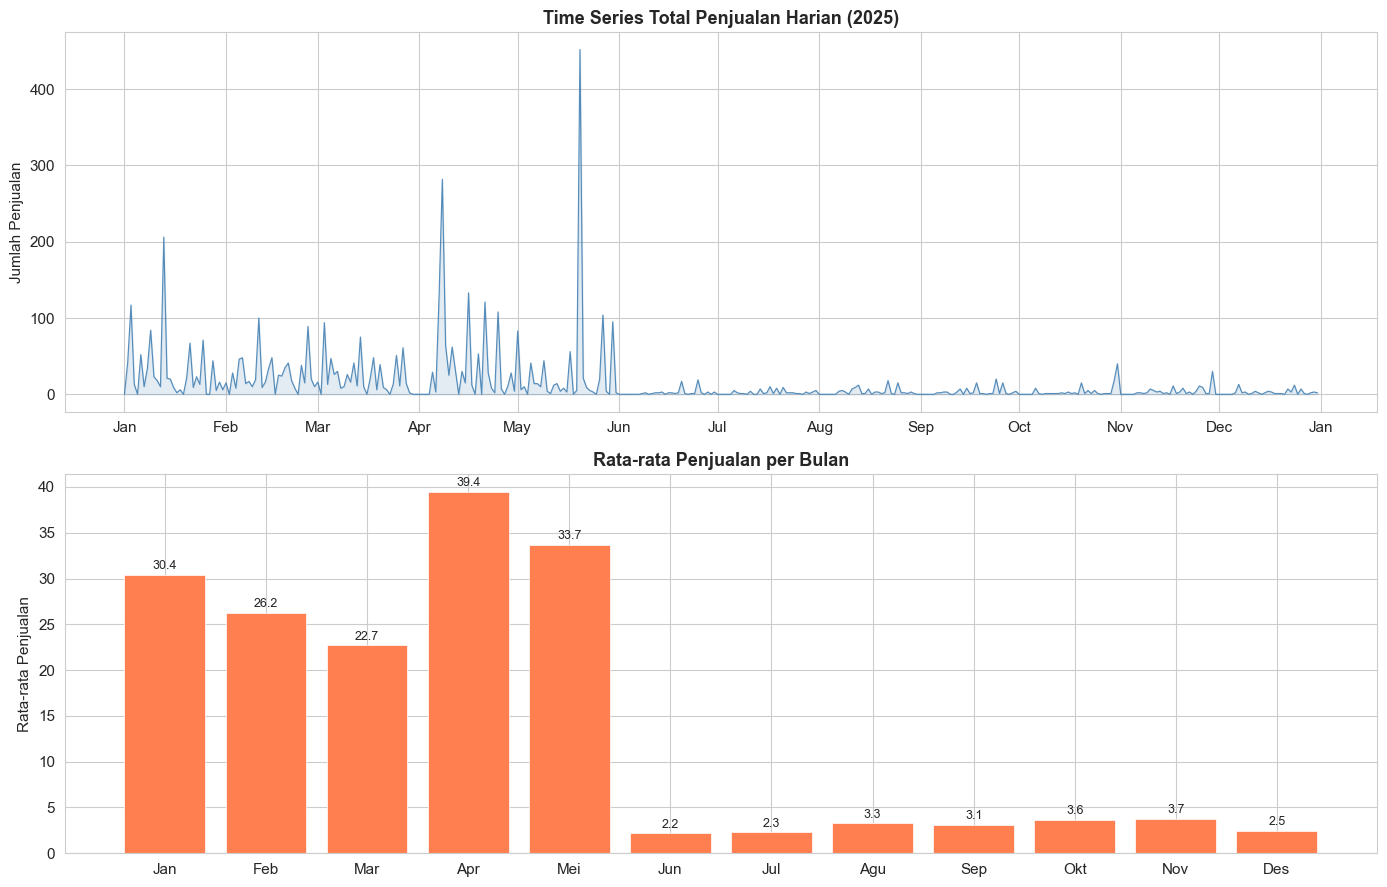

In [5]:
# Time series Total_Sales
fig, axes = plt.subplots(2, 1, figsize=(14, 9))

axes[0].plot(df['Date'], df['Total_Sales'], color='steelblue', linewidth=0.85, alpha=0.9)
axes[0].fill_between(df['Date'], df['Total_Sales'], alpha=0.15, color='steelblue')
axes[0].set_title('Time Series Total Penjualan Harian (2025)', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Jumlah Penjualan')
axes[0].xaxis.set_major_formatter(mdates.DateFormatter('%b'))
axes[0].xaxis.set_major_locator(mdates.MonthLocator())

# Rata-rata per bulan
monthly = df.groupby('Month')['Total_Sales'].mean()
months  = ['Jan','Feb','Mar','Apr','Mei','Jun','Jul','Agu','Sep','Okt','Nov','Des']
bars = axes[1].bar(months, monthly.values, color='coral', edgecolor='white', linewidth=0.5)
axes[1].bar_label(bars, fmt='%.1f', fontsize=9, padding=2)
axes[1].set_title('Rata-rata Penjualan per Bulan', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Rata-rata Penjualan')

plt.tight_layout()
plt.show()

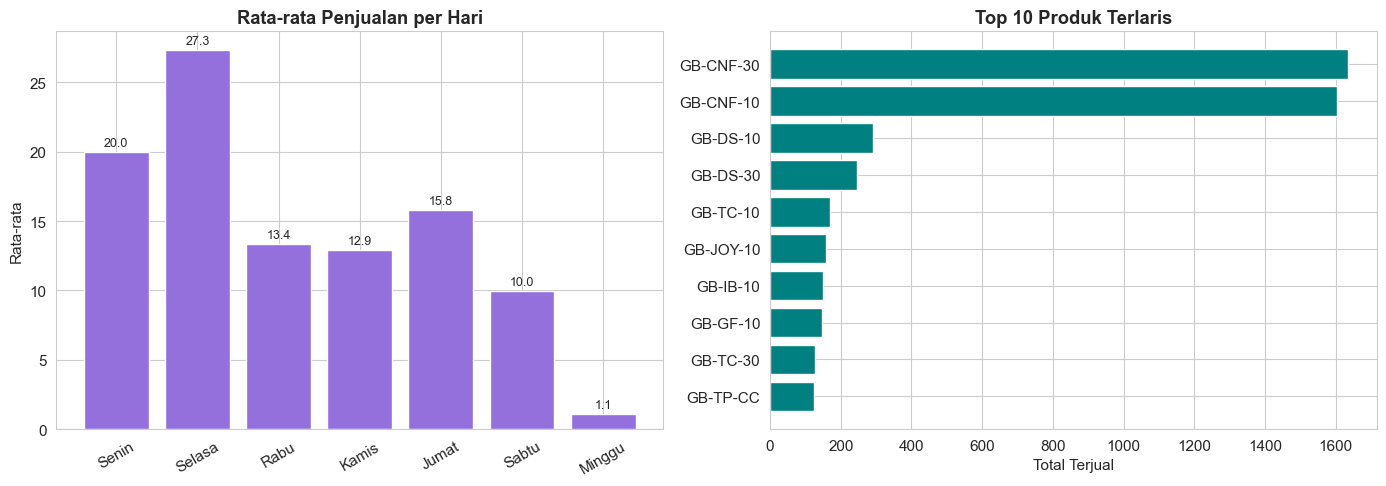

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Rata-rata per hari dalam seminggu
day_names = ['Senin','Selasa','Rabu','Kamis','Jumat','Sabtu','Minggu']
daily_avg = df.groupby('DayOfWeek')['Total_Sales'].mean()
bars = axes[0].bar(day_names, daily_avg.values, color='mediumpurple', edgecolor='white')
axes[0].bar_label(bars, fmt='%.1f', fontsize=9, padding=2)
axes[0].set_title('Rata-rata Penjualan per Hari', fontweight='bold')
axes[0].set_ylabel('Rata-rata')
axes[0].tick_params(axis='x', rotation=30)

# Top 10 produk terlaris
top10_vals = df[prod_cols].sum().sort_values(ascending=True).tail(10)
axes[1].barh(top10_vals.index, top10_vals.values, color='teal', edgecolor='white')
axes[1].set_title('Top 10 Produk Terlaris', fontweight='bold')
axes[1].set_xlabel('Total Terjual')

plt.tight_layout()
plt.show()

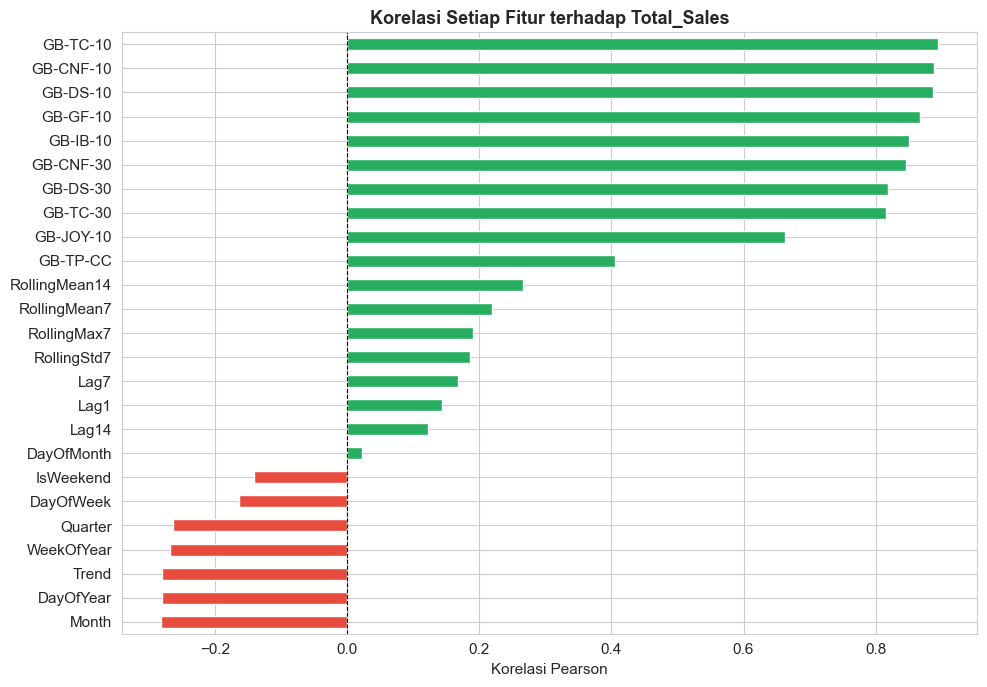

Top 5 Fitur Korelasi Tertinggi:
GB-TC-10     0.8944
GB-CNF-10    0.8883
GB-DS-10     0.8866
GB-GF-10     0.8666
GB-IB-10     0.8509
Name: Total_Sales, dtype: float64


In [7]:
# Heatmap korelasi fitur utama dengan Total_Sales
corr_cols = TIME_FEATS + top10_products + ['Total_Sales']
corr = df_model[corr_cols].corr()['Total_Sales'].drop('Total_Sales').sort_values()

plt.figure(figsize=(10, 7))
colors = ['#e74c3c' if v < 0 else '#27ae60' for v in corr.values]
corr.plot(kind='barh', color=colors)
plt.axvline(0, color='black', linewidth=0.8, linestyle='--')
plt.title('Korelasi Setiap Fitur terhadap Total_Sales', fontsize=13, fontweight='bold')
plt.xlabel('Korelasi Pearson')
plt.tight_layout()
plt.show()

print('Top 5 Fitur Korelasi Tertinggi:')
print(corr.abs().sort_values(ascending=False).head(5).round(4))

---
## 5. ✂️ Split Data & Normalisasi

In [8]:
X = df_model[FEATURE_COLS]
y = df_model['Total_Sales']
dates_model = df_model['Date']

# Split 80% train / 20% test — urutan waktu dipertahankan
split_idx = int(len(X) * 0.8)

X_train, X_test = X.iloc[:split_idx],      X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx],      y.iloc[split_idx:]
dates_train     = dates_model.iloc[:split_idx]
dates_test      = dates_model.iloc[split_idx:]

# Normalisasi dengan StandardScaler
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

print(f'📂 Data Training : {len(X_train)} baris '
      f'({dates_train.min().date()} – {dates_train.max().date()})')
print(f'📂 Data Testing  : {len(X_test)} baris '
      f'({dates_test.min().date()} – {dates_test.max().date()})')
print(f'🔢 Jumlah Fitur  : {X_train.shape[1]}')

📂 Data Training : 280 baris (2025-01-15 – 2025-10-21)
📂 Data Testing  : 71 baris (2025-10-22 – 2025-12-31)
🔢 Jumlah Fitur  : 25


---
## 6. 🤖 Training Model Regresi Linier

In [9]:
model = LinearRegression()
model.fit(X_train_sc, y_train)

# Prediksi (clipping agar tidak negatif)
y_pred_train = np.clip(model.predict(X_train_sc), 0, None)
y_pred_test  = np.clip(model.predict(X_test_sc),  0, None)

print('✅ Model berhasil dilatih!')
print(f'   Intercept   : {model.intercept_:.4f}')
print(f'   Jumlah fitur: {len(model.coef_)}')

✅ Model berhasil dilatih!
   Intercept   : 15.5286
   Jumlah fitur: 25


---
## 7. 📏 Evaluasi Model

In [10]:
def evaluate(y_true, y_pred, label):
    mae  = mean_absolute_error(y_true, y_pred)
    mse  = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2   = r2_score(y_true, y_pred)
    mask = y_true > 0
    mape = mean_absolute_percentage_error(y_true[mask], y_pred[mask]) * 100
    print(f"\n{'='*42}")
    print(f"  EVALUASI: {label}")
    print(f"{'='*42}")
    print(f"  MAE    : {mae:.4f}")
    print(f"  MSE    : {mse:.4f}")
    print(f"  RMSE   : {rmse:.4f}")
    print(f"  R²     : {r2:.4f}  ({r2*100:.2f}%)")
    print(f"  MAPE   : {mape:.2f}%  (hanya data > 0)")
    return dict(MAE=mae, MSE=mse, RMSE=rmse, R2=r2, MAPE=mape)

m_train = evaluate(y_train, y_pred_train, 'DATA TRAINING')
m_test  = evaluate(y_test,  y_pred_test,  'DATA TESTING')


  EVALUASI: DATA TRAINING
  MAE    : 1.0613
  MSE    : 3.2527
  RMSE   : 1.8035
  R²     : 0.9978  (99.78%)
  MAPE   : 23.80%  (hanya data > 0)

  EVALUASI: DATA TESTING
  MAE    : 0.5753
  MSE    : 0.9302
  RMSE   : 0.9645
  R²     : 0.9778  (97.78%)
  MAPE   : 37.86%  (hanya data > 0)


In [11]:
# Cross-Validation 5-fold pada data training
cv_r2  = cross_val_score(LinearRegression(), X_train_sc, y_train, cv=5, scoring='r2')
cv_mae = cross_val_score(LinearRegression(), X_train_sc, y_train, cv=5,
                         scoring='neg_mean_absolute_error')

print('Cross-Validation (5-fold) pada Training Set:')
print(f'  R²   per fold : {[round(v,4) for v in cv_r2]}')
print(f'  R²   mean±std : {cv_r2.mean():.4f} ± {cv_r2.std():.4f}')
print(f'  MAE  mean±std : {(-cv_mae).mean():.4f} ± {(-cv_mae).std():.4f}')

Cross-Validation (5-fold) pada Training Set:
  R²   per fold : [np.float64(0.9869), np.float64(0.997), np.float64(0.9983), np.float64(0.8071), np.float64(0.916)]
  R²   mean±std : 0.9411 ± 0.0736
  MAE  mean±std : 1.3166 ± 0.4590


In [12]:
# Tabel ringkasan metrik
metrics_df = pd.DataFrame({
    'Training': [m_train['MAE'], m_train['MSE'], m_train['RMSE'],
                 m_train['R2'],  m_train['MAPE']],
    'Testing' : [m_test['MAE'],  m_test['MSE'],  m_test['RMSE'],
                 m_test['R2'],   m_test['MAPE']]
}, index=['MAE','MSE','RMSE','R²','MAPE (%)'])
print('\n📊 Ringkasan Metrik Evaluasi:')
metrics_df.round(4)


📊 Ringkasan Metrik Evaluasi:


,Training,Testing
MAE,1.0613,0.5753
MSE,3.2527,0.9302
RMSE,1.8035,0.9645
R²,0.9978,0.9778
MAPE (%),23.8030,37.8607


---
## 8. 📈 Visualisasi Hasil Prediksi

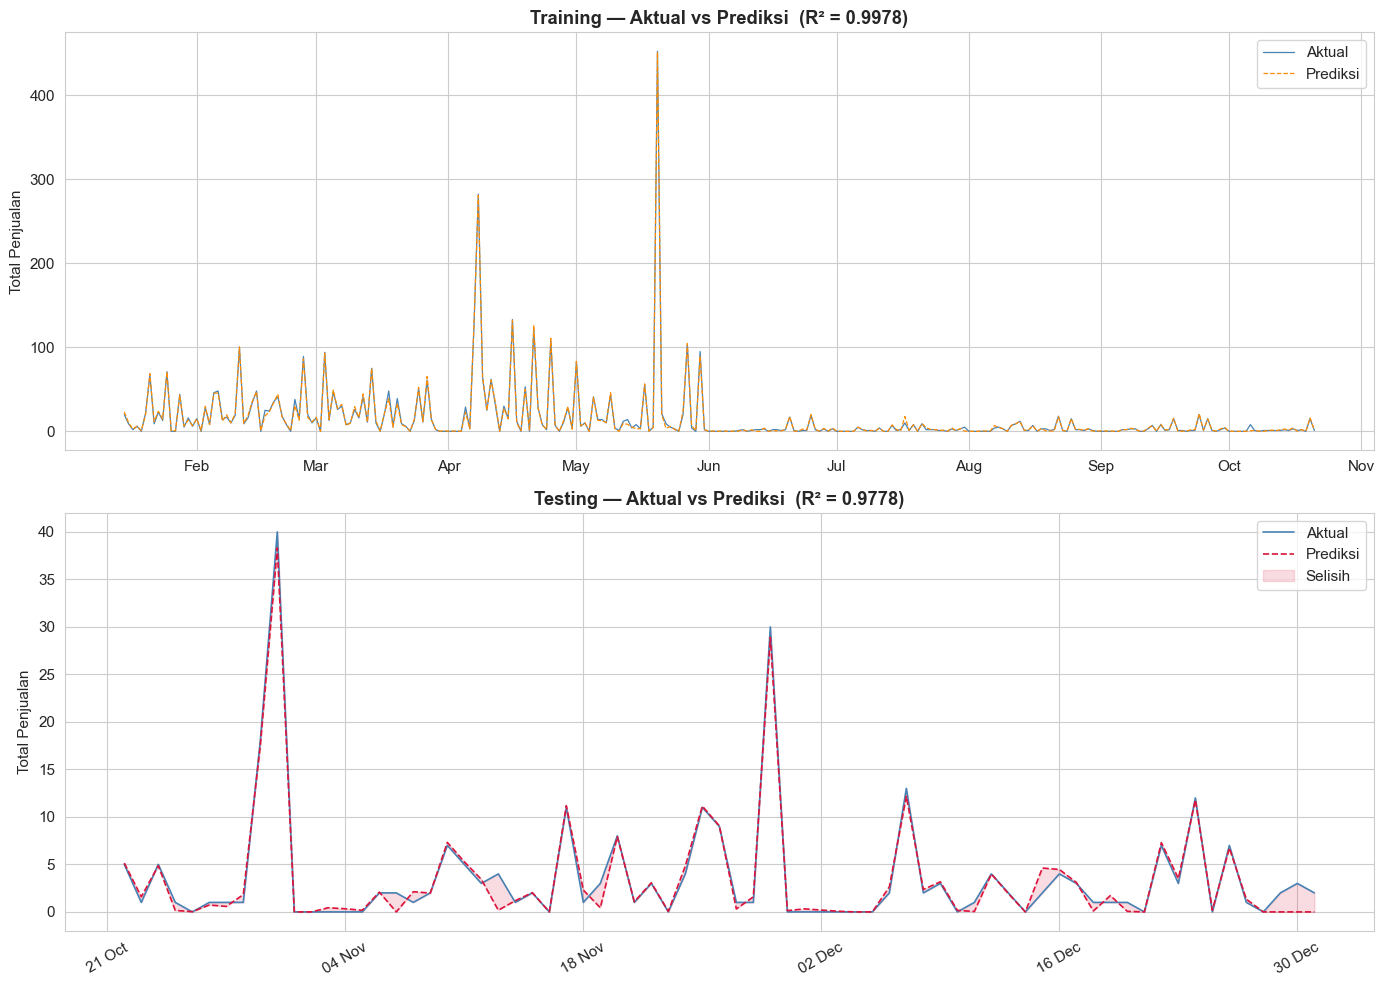

In [13]:
# Aktual vs Prediksi – Training & Testing
fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# Training
axes[0].plot(dates_train, y_train.values,  label='Aktual',   color='steelblue',  lw=0.9)
axes[0].plot(dates_train, y_pred_train,    label='Prediksi', color='darkorange', lw=0.9, ls='--')
axes[0].set_title(f'Training — Aktual vs Prediksi  (R² = {m_train["R2"]:.4f})',
                  fontweight='bold')
axes[0].set_ylabel('Total Penjualan')
axes[0].legend()
axes[0].xaxis.set_major_formatter(mdates.DateFormatter('%b'))
axes[0].xaxis.set_major_locator(mdates.MonthLocator())

# Testing
axes[1].plot(dates_test, y_test.values, label='Aktual',   color='steelblue', lw=1.2)
axes[1].plot(dates_test, y_pred_test,   label='Prediksi', color='crimson',   lw=1.2, ls='--')
axes[1].fill_between(dates_test,
                     y_test.values, y_pred_test,
                     alpha=0.15, color='crimson', label='Selisih')
axes[1].set_title(f'Testing — Aktual vs Prediksi  (R² = {m_test["R2"]:.4f})',
                  fontweight='bold')
axes[1].set_ylabel('Total Penjualan')
axes[1].legend()
axes[1].xaxis.set_major_formatter(mdates.DateFormatter('%d %b'))
axes[1].xaxis.set_major_locator(mdates.WeekdayLocator(interval=2))
plt.setp(axes[1].xaxis.get_majorticklabels(), rotation=30)

plt.tight_layout()
plt.show()

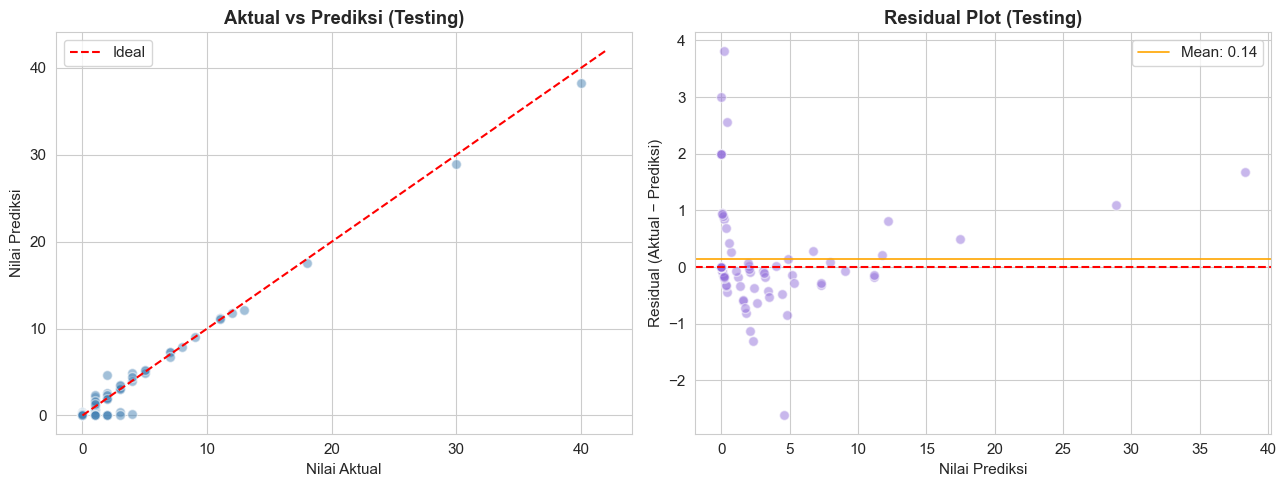

In [14]:
# Scatter plot & Residual plot
residuals = y_test.values - y_pred_test

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Scatter: Aktual vs Prediksi
axes[0].scatter(y_test, y_pred_test, alpha=0.5, s=50,
                color='steelblue', edgecolors='white')
lim = max(y_test.max(), y_pred_test.max()) * 1.05
axes[0].plot([0, lim], [0, lim], 'r--', lw=1.5, label='Ideal')
axes[0].set_xlabel('Nilai Aktual')
axes[0].set_ylabel('Nilai Prediksi')
axes[0].set_title('Aktual vs Prediksi (Testing)', fontweight='bold')
axes[0].legend()

# Residual plot
axes[1].scatter(y_pred_test, residuals, alpha=0.5, s=50,
                color='mediumpurple', edgecolors='white')
axes[1].axhline(0,               color='red',    ls='--', lw=1.5)
axes[1].axhline(residuals.mean(),color='orange', ls='-',  lw=1.2,
                label=f'Mean: {residuals.mean():.2f}')
axes[1].set_xlabel('Nilai Prediksi')
axes[1].set_ylabel('Residual (Aktual − Prediksi)')
axes[1].set_title('Residual Plot (Testing)', fontweight='bold')
axes[1].legend()

plt.tight_layout()
plt.show()

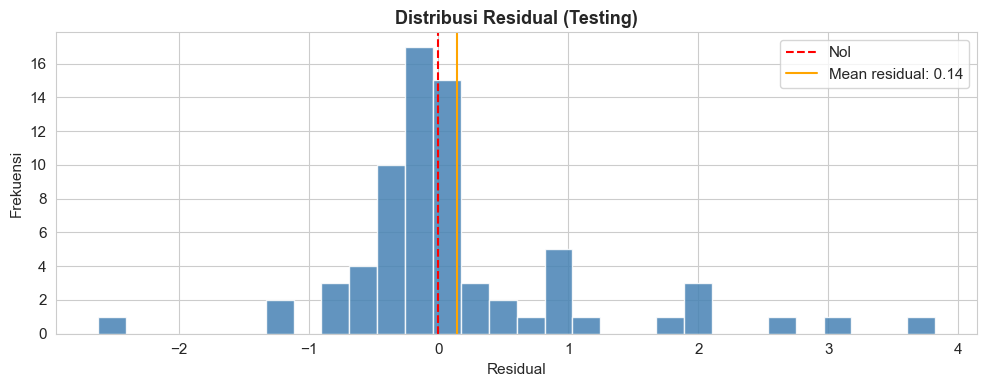

Std residual: 0.9544


In [15]:
# Distribusi residual
plt.figure(figsize=(10, 4))
plt.hist(residuals, bins=30, color='steelblue', edgecolor='white', alpha=0.85)
plt.axvline(0,               color='red',    ls='--', lw=1.5, label='Nol')
plt.axvline(residuals.mean(),color='orange', ls='-',  lw=1.5,
            label=f'Mean residual: {residuals.mean():.2f}')
plt.title('Distribusi Residual (Testing)', fontsize=13, fontweight='bold')
plt.xlabel('Residual')
plt.ylabel('Frekuensi')
plt.legend()
plt.tight_layout()
plt.show()
print(f'Std residual: {residuals.std():.4f}')

---
## 9. 🏅 Feature Importance (Koefisien Regresi)

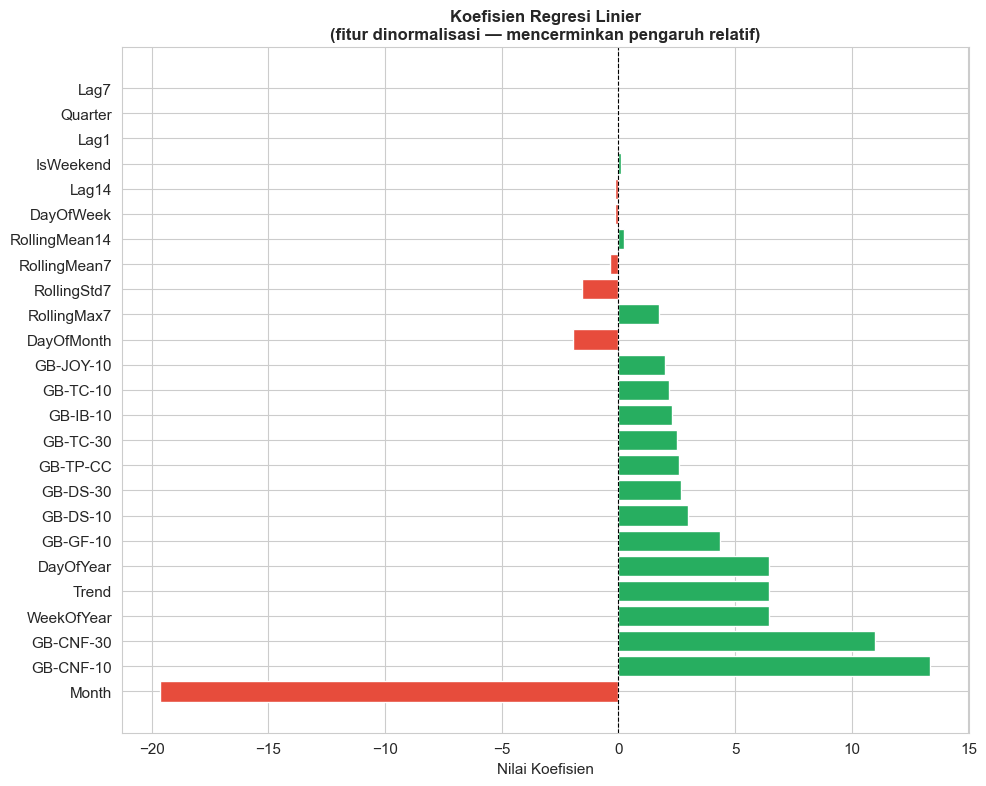


📋 Top 10 Fitur Paling Berpengaruh:
     Fitur  Koefisien
     Month -19.633202
 GB-CNF-10  13.360433
 GB-CNF-30  11.001139
WeekOfYear   6.440171
     Trend   6.439552
 DayOfYear   6.439552
  GB-GF-10   4.332863
  GB-DS-10   2.993320
  GB-DS-30   2.680763
  GB-TP-CC   2.587852


In [16]:
coef_df = pd.DataFrame({
    'Fitur'     : FEATURE_COLS,
    'Koefisien' : model.coef_
}).sort_values('Koefisien', key=abs, ascending=False)

plt.figure(figsize=(10, 8))
colors = ['#e74c3c' if v < 0 else '#27ae60' for v in coef_df['Koefisien']]
plt.barh(coef_df['Fitur'], coef_df['Koefisien'], color=colors, edgecolor='white')
plt.axvline(0, color='black', lw=0.8, ls='--')
plt.title('Koefisien Regresi Linier\n(fitur dinormalisasi — mencerminkan pengaruh relatif)',
          fontsize=12, fontweight='bold')
plt.xlabel('Nilai Koefisien')
plt.tight_layout()
plt.show()

print('\n📋 Top 10 Fitur Paling Berpengaruh:')
print(coef_df.head(10).to_string(index=False))

---
## 10. 📋 Tabel Perbandingan: Aktual vs Prediksi

In [17]:
# Tampilkan semua data testing
result_df = pd.DataFrame({
    'Tanggal' : dates_test.dt.strftime('%Y-%m-%d').values,
    'Aktual'  : y_test.values.round(0).astype(int),
    'Prediksi': y_pred_test.round(0).astype(int),
    'Selisih' : (y_test.values - y_pred_test).round(0).astype(int),
    'Error %' : np.where(
        y_test.values > 0,
        (np.abs(y_test.values - y_pred_test) / y_test.values * 100).round(1),
        np.nan
    )
})

print(f'Tabel hasil prediksi ({len(result_df)} data testing):')
result_df

Tabel hasil prediksi (71 data testing):


,Tanggal,Aktual,Prediksi,Selisih,Error %
0,2025-10-22,5,5,0,2.8
1,2025-10-23,1,2,-1,59.4
2,2025-10-24,5,5,0,2.9
3,2025-10-25,1,0,1,84.3
4,2025-10-26,0,0,0,NaN
...,...,...,...,...,...
66,2025-12-27,1,1,0,33.2
67,2025-12-28,0,0,0,NaN
68,2025-12-29,2,0,2,100.0
69,2025-12-30,3,0,3,100.0


---
## 11. 💾 Simpan Hasil Prediksi ke Excel

In [18]:
output_file = 'Hasil_Regresi_Linier.xlsx'
result_df.to_excel(output_file, index=False, sheet_name='Prediksi_Testing')
print(f'✅ Hasil prediksi disimpan ke: {output_file}')

✅ Hasil prediksi disimpan ke: Hasil_Regresi_Linier.xlsx


---
## 12. 🏁 Ringkasan & Kesimpulan

In [19]:
print('=' * 56)
print('      RINGKASAN HASIL REGRESI LINIER')
print('=' * 56)
print(f'  File       : {FILE}')
print(f'  Target     : Total_Sales (penjualan harian)')
print(f'  Fitur      : {len(FEATURE_COLS)} (kalender + lag + rolling + produk)')
print(f'  Train/Test : {len(X_train)}/{len(X_test)} baris (80/20)')
print()
print('  ── HASIL TESTING ──')
print(f'  R²   : {m_test["R2"]*100:.2f}%')
print(f'  MAE  : {m_test["MAE"]:.2f} unit')
print(f'  RMSE : {m_test["RMSE"]:.2f} unit')
print(f'  MAPE : {m_test["MAPE"]:.2f}% (data non-zero)')
print()
print('  ── INTERPRETASI ──')
if m_test['R2'] >= 0.8:
    print('  ✅ Model BAIK (R² ≥ 80%)')
elif m_test['R2'] >= 0.6:
    print('  ⚠️  Model CUKUP BAIK (R² 60–80%)')
elif m_test['R2'] >= 0.4:
    print('  ⚠️  Model SEDANG (R² 40–60%) — coba tambah fitur')
else:
    print('  ❌ Model LEMAH (R² < 40%) — pertimbangkan model non-linier')
print()
print('  ── TOP 3 FITUR PALING BERPENGARUH ──')
for _, row in coef_df.head(3).iterrows():
    arah = '↑ positif' if row['Koefisien'] > 0 else '↓ negatif'
    print(f'    {row["Fitur"]:20s}  koef={row["Koefisien"]:+.3f}  ({arah})')
print('=' * 56)

      RINGKASAN HASIL REGRESI LINIER
  File       : Dataset_Forecasting_ARIMA_Lengkap.xlsx
  Target     : Total_Sales (penjualan harian)
  Fitur      : 25 (kalender + lag + rolling + produk)
  Train/Test : 280/71 baris (80/20)

  ── HASIL TESTING ──
  R²   : 97.78%
  MAE  : 0.58 unit
  RMSE : 0.96 unit
  MAPE : 37.86% (data non-zero)

  ── INTERPRETASI ──
  ✅ Model BAIK (R² ≥ 80%)

  ── TOP 3 FITUR PALING BERPENGARUH ──
    Month                 koef=-19.633  (↓ negatif)
    GB-CNF-10             koef=+13.360  (↑ positif)
    GB-CNF-30             koef=+11.001  (↑ positif)
